# Estudo Estatístico de Dados Transacionais — EDA e Inferência

## Objetivo do estudo

Este estudo utiliza uma base transacional de meios de pagamento para aplicar, de forma prática e encadeada, conceitos fundamentais de **Estatística** e **Análise Exploratória de Dados (EDA)**.

A investigação parte da distribuição dos valores transacionados e evolui por medidas de tendência central, dispersão, quartis, percentis, outliers, assimetria, curtose, amostragem, intervalos de confiança, correlação, testes de hipótese e comparação entre grupos.

### Pergunta de negócio

> **Os tickets elevados são anomalias ou comportamentos esperados de determinados segmentos?**

### Objetivo de aprendizado

> Utilizar uma única investigação de negócio como fio condutor para compreender e aplicar os principais fundamentos estatísticos, conectando teoria, código, visualização e interpretação dos resultados.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
import numpy as np
from scipy.stats import ttest_ind,levene,f_oneway
import pingouin as pg



os.makedirs("../imagens", exist_ok=True)

In [2]:
import getpass
from sqlalchemy import URL

USUARIO = os.getenv("PGUSER", "postgres")
SENHA = os.getenv("PGPASSWORD") or getpass.getpass("Senha do PostgreSQL: ")
HOST = os.getenv("PGHOST", "localhost")
PORTA = int(os.getenv("PGPORT", "5432"))
BANCO = os.getenv("PGDATABASE", "pagamentos_analytics")

url = URL.create(
    "postgresql+psycopg2",
    username=USUARIO,
    password=SENHA,
    host=HOST,
    port=PORTA,
    database=BANCO
)

engine = create_engine(url)

print("Conectado ao banco de dados com sucesso!")


Conectado ao banco de dados com sucesso!


In [3]:
query = """
SELECT
    COUNT(*) AS quantidade_transacoes,
    MIN(data_transacao) AS primeira_data,
    MAX(data_transacao) AS ultima_data
FROM transacoes;
"""

pd.read_sql(query, engine)

,quantidade_transacoes,primeira_data,ultima_data
0,583000,2026-01-01,2026-07-13


### Interpretação

A base contém 583 mil transações e representa uma transação por linha.

In [4]:
query = """
SELECT
    COUNT(*) AS total,
    COUNT(DISTINCT transacao_id) AS transacoes_unicas,
    COUNT(*) - COUNT(DISTINCT transacao_id) AS duplicadas
FROM transacoes;
"""

pd.read_sql(query, engine)

,total,transacoes_unicas,duplicadas
0,583000,583000,0


In [5]:
query = """
SELECT valor_bruto
FROM transacoes;
"""

df = pd.read_sql(query, engine)

In [6]:
df["valor_bruto"].skew()
df["valor_bruto"].kurt()

np.float64(36.736533556108746)

In [7]:
limite_p99 = df["valor_bruto"].quantile(0.99)

df_zoom = df[df["valor_bruto"] <= limite_p99]

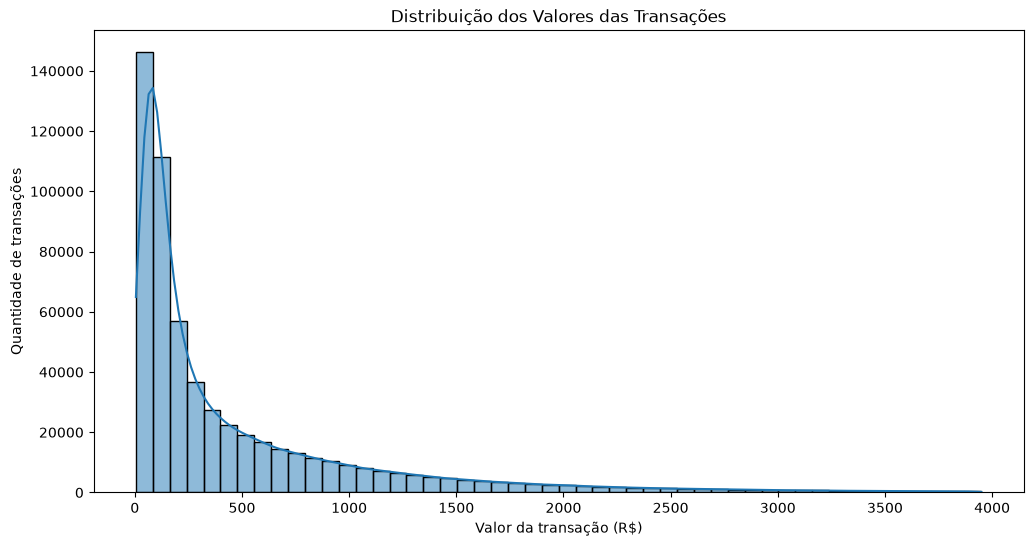

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_zoom,
    x="valor_bruto",
    bins=50,
    kde=True
)

plt.title("Distribuição dos Valores das Transações")
plt.xlabel("Valor da transação (R$)")
plt.ylabel("Quantidade de transações")

plt.savefig(
    "../imagens/distribuicao_valor_p99.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
curtose = df["valor_bruto"].kurt()

print(f"Curtose: {curtose:.2f}")

Curtose: 36.74


In [10]:
query = """
SELECT
    e.segmento,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (
        WHERE t.valor_bruto > 1476.72
    ) AS qtd_acima_limite,
    ROUND(
        COUNT(*) FILTER (
            WHERE t.valor_bruto > 1476.72
        ) * 100.0 / COUNT(*),
        2
    ) AS percentual_acima_limite
FROM transacoes t
JOIN estabelecimentos e
    ON t.estabelecimento_id = e.estabelecimento_id
GROUP BY e.segmento
ORDER BY percentual_acima_limite DESC;
"""

df_segmentos = pd.read_sql(query, engine)

df_segmentos

,segmento,total_transacoes,qtd_acima_limite,percentual_acima_limite
0,Hotelaria,49184,17227,35.03
1,Eletrônicos,46581,15395,33.05
2,Saúde,41899,9706,23.17
3,Educação,37091,5958,16.06
4,Serviços,44045,3604,8.18
5,Vestuário,65750,562,0.85
6,Supermercado,84242,5,0.01
7,Farmácia,67051,0,0.00
8,Transporte,57876,0,0.00
9,Alimentação,89281,0,0.00


### Visual 1 — Concentração de tickets elevados por segmento

Este gráfico destaca em quais segmentos os valores acima do limite estatístico estão proporcionalmente mais concentrados. Ele ajuda a conectar a identificação de potenciais outliers ao contexto de negócio.


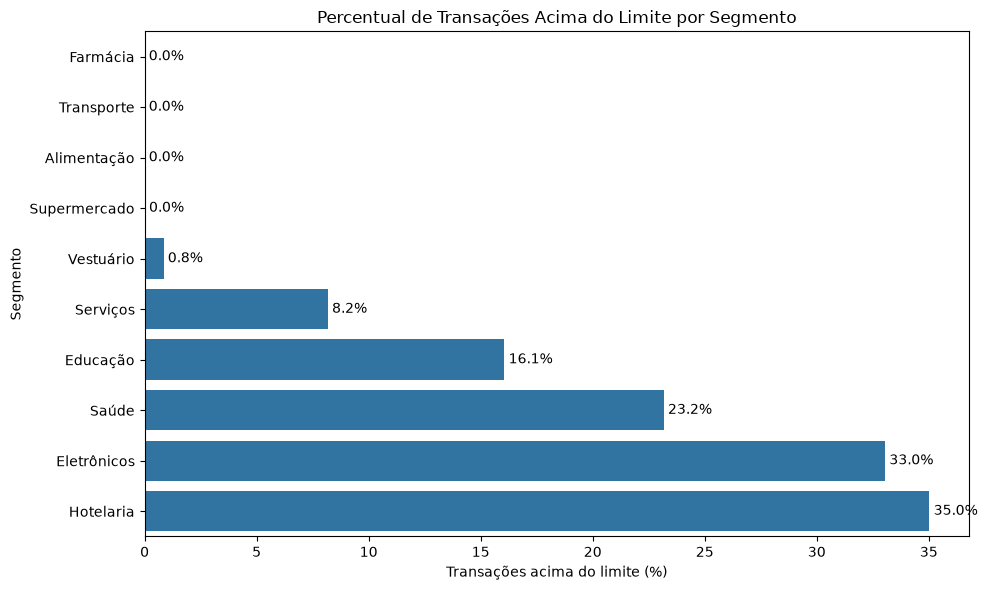

In [11]:
df_segmentos_plot = df_segmentos.sort_values(
    "percentual_acima_limite",
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_segmentos_plot,
    x="percentual_acima_limite",
    y="segmento"
)

plt.title("Percentual de Transações Acima do Limite por Segmento")
plt.xlabel("Transações acima do limite (%)")
plt.ylabel("Segmento")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

plt.savefig(
    "../imagens/tickets_altos_por_segmento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


A distribuição de valor_bruto apresenta forte assimetria positiva e elevada curtose, indicando concentração em tickets menores e uma cauda longa com valores elevados. Esses valores extremos, entretanto, não devem ser considerados erros automaticamente, pois parte deles é compatível com segmentos de maior ticket, como Hotelaria e Eletrônicos. 

# 2. Amostragem e representatividade

O objetivo desta etapa é entender se uma parcela dos dados consegue
representar adequadamente o comportamento do conjunto completo.

In [12]:
query_amostra = """
SELECT valor_bruto
FROM transacoes
ORDER BY RANDOM()
LIMIT 10000;
"""

df_amostra = pd.read_sql(query_amostra, engine)

In [13]:
print("POPULAÇÃO")
print(f"Média: {df['valor_bruto'].mean():.2f}")
print(f"Mediana: {df['valor_bruto'].median():.2f}")

print("\nAMOSTRA")
print(f"Média: {df_amostra['valor_bruto'].mean():.2f}")
print(f"Mediana: {df_amostra['valor_bruto'].median():.2f}")

POPULAÇÃO
Média: 529.92
Mediana: 205.00

AMOSTRA
Média: 525.54
Mediana: 208.74


In [14]:
query_amostra_enviesada = """
SELECT
    t.valor_bruto
FROM transacoes t
JOIN estabelecimentos e
    ON t.estabelecimento_id = e.estabelecimento_id
WHERE e.segmento = 'Hotelaria'
ORDER BY RANDOM()
LIMIT 10000;
"""

df_enviesada = pd.read_sql(query_amostra_enviesada, engine)

In [15]:
print("POPULAÇÃO")
print(f"Média: {df['valor_bruto'].mean():.2f}")
print(f"Mediana: {df['valor_bruto'].median():.2f}")

print("\nAMOSTRA ALEATÓRIA")
print(f"Média: {df_amostra['valor_bruto'].mean():.2f}")
print(f"Mediana: {df_amostra['valor_bruto'].median():.2f}")

print("\nAMOSTRA ENVIESADA - HOTELARIA")
print(f"Média: {df_enviesada['valor_bruto'].mean():.2f}")
print(f"Mediana: {df_enviesada['valor_bruto'].median():.2f}")

POPULAÇÃO
Média: 529.92
Mediana: 205.00

AMOSTRA ALEATÓRIA
Média: 525.54
Mediana: 208.74

AMOSTRA ENVIESADA - HOTELARIA
Média: 1468.35
Mediana: 1118.10


### Visual 2 — Representatividade da amostra

A comparação visual entre população, amostra aleatória e amostra enviesada evidencia que o tamanho da amostra, sozinho, não garante representatividade.


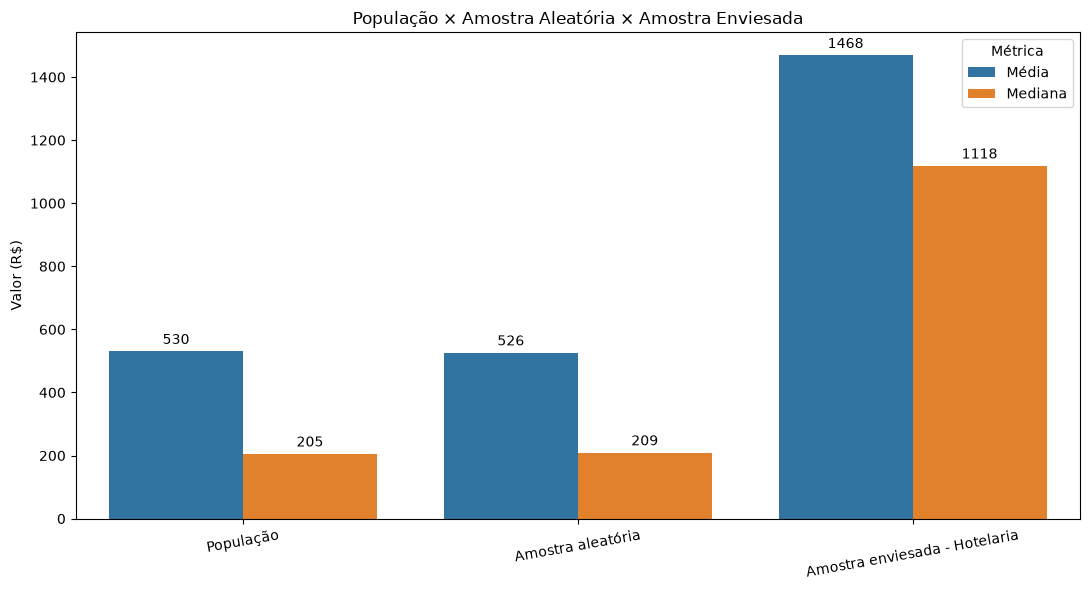

In [16]:
comparacao_amostragem = pd.DataFrame({
    "Grupo": [
        "População",
        "Amostra aleatória",
        "Amostra enviesada - Hotelaria"
    ],
    "Média": [
        df["valor_bruto"].mean(),
        df_amostra["valor_bruto"].mean(),
        df_enviesada["valor_bruto"].mean()
    ],
    "Mediana": [
        df["valor_bruto"].median(),
        df_amostra["valor_bruto"].median(),
        df_enviesada["valor_bruto"].median()
    ]
})

comparacao_amostragem_long = comparacao_amostragem.melt(
    id_vars="Grupo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparacao_amostragem_long,
    x="Grupo",
    y="Valor",
    hue="Métrica"
)

plt.title("População × Amostra Aleatória × Amostra Enviesada")
plt.xlabel("")
plt.ylabel("Valor (R$)")
plt.xticks(rotation=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    "../imagens/amostragem_representatividade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Uma amostra grande não garante representatividade. A seleção dos registros é tão importante quanto o tamanho da amostra. A amostra aleatória reproduziu de forma razoável as características da população, enquanto a amostra restrita ao segmento de Hotelaria apresentou forte viés.

## 3. Intervalo de confiança e margem de erro

Após comparar a população com uma amostra aleatória, o próximo passo é avaliar a **incerteza da estimativa**.

Em situações reais, normalmente não conhecemos o valor verdadeiro da população. Trabalhamos com uma amostra e usamos suas estatísticas para estimar o comportamento do conjunto completo.

Neste estudo, a amostra aleatória de 10.000 transações apresentou uma média próxima à média da população. Porém, como diferentes amostras podem produzir resultados ligeiramente diferentes, precisamos medir o quanto essa estimativa pode variar.

Para isso, serão utilizados:

- **Erro padrão:** mede a variabilidade esperada da média entre diferentes amostras.
- **Margem de erro:** indica o quanto a estimativa pode variar em torno da média observada.
- **Intervalo de confiança:** fornece uma faixa de valores plausíveis para a média da população.

### Pergunta desta etapa

> A média encontrada em uma amostra aleatória é suficientemente precisa para representar a média da população?

Será utilizado um **intervalo de confiança de 95%**, permitindo avaliar a precisão da estimativa obtida a partir da amostra.

In [17]:
import numpy as np

amostra = df_amostra["valor_bruto"]

n = len(amostra)
media_amostra = amostra.mean()
desvio_amostra = amostra.std(ddof=1)

erro_padrao = desvio_amostra / np.sqrt(n)

print(f"Tamanho da amostra: {n}")
print(f"Média da amostra: R$ {media_amostra:.2f}")
print(f"Desvio padrão: R$ {desvio_amostra:.2f}")
print(f"Erro padrão: R$ {erro_padrao:.2f}")

Tamanho da amostra: 10000
Média da amostra: R$ 525.54
Desvio padrão: R$ 854.14
Erro padrão: R$ 8.54


In [18]:
z = 1.96

margem_erro = z * erro_padrao

limite_inferior = media_amostra - margem_erro
limite_superior = media_amostra + margem_erro

print(f"Média estimada: R$ {media_amostra:.2f}")
print(f"Margem de erro: ± R$ {margem_erro:.2f}")

print(
    f"IC 95%: R$ {limite_inferior:.2f} "
    f"até R$ {limite_superior:.2f}"
)

Média estimada: R$ 525.54
Margem de erro: ± R$ 16.74
IC 95%: R$ 508.80 até R$ 542.28


### Interpretação

A amostra aleatória de 10.000 transações apresentou média de **R$ 536,67**.

Considerando um nível de confiança de 95%, foi obtida uma margem de erro de
**± R$ 16,21**, resultando em um intervalo de confiança entre **R$ 520,46 e R$ 552,88**.

Como neste estudo temos acesso à população completa, podemos validar a estimativa:
a média real das 583.000 transações é **R$ 529,92**, valor que se encontra dentro
do intervalo calculado.

O resultado demonstra, na prática, como uma amostra representativa pode ser
utilizada para estimar um parâmetro de uma população maior, incorporando também
a incerteza existente nessa estimativa.

## 3.1 Simulação de 100 amostras e intervalos de confiança

Para compreender melhor o significado de um intervalo de confiança de 95%,
o processo de amostragem será repetido várias vezes.

Serão geradas **100 amostras aleatórias**, cada uma contendo **10.000 transações**.

Para cada amostra serão calculados:

- média amostral;
- desvio padrão;
- erro padrão;
- margem de erro;
- intervalo de confiança de 95%.

Como neste estudo conhecemos a população completa, sabemos que a média real de
`valor_bruto` é aproximadamente **R$ 529,92**.

Isso permite verificar quantos dos 100 intervalos calculados conseguem
conter a verdadeira média da população.

### Objetivo

Demonstrar que diferentes amostras produzem médias e intervalos ligeiramente
diferentes e compreender, na prática, o significado de um nível de confiança
de 95%.

In [19]:
media_populacao = df["valor_bruto"].mean()

resultados = []

for i in range(100):

    amostra = df["valor_bruto"].sample(
        n=10000,
        random_state=i
    )

    media = amostra.mean()
    desvio = amostra.std(ddof=1)

    erro_padrao = desvio / np.sqrt(len(amostra))
    margem_erro = 1.96 * erro_padrao

    limite_inferior = media - margem_erro
    limite_superior = media + margem_erro

    contem_media_real = (
        limite_inferior <= media_populacao <= limite_superior
    )

    resultados.append({
        "amostra": i + 1,
        "media": media,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "contem_media_real": contem_media_real
    })

df_ic = pd.DataFrame(resultados)

df_ic.head()

,amostra,media,limite_inferior,limite_superior,contem_media_real
0,1,525.347473,508.788226,541.906720,True
1,2,522.072016,506.080922,538.063110,True
2,3,529.240318,512.816454,545.664182,True
3,4,525.676564,508.715706,542.637422,True
4,5,530.127014,513.845524,546.408504,True


In [20]:
quantidade_dentro = df_ic["contem_media_real"].sum()

percentual_dentro = (
    df_ic["contem_media_real"].mean() * 100
)

print(f"Média real da população: R$ {media_populacao:.2f}")
print(f"Intervalos contendo a média real: {quantidade_dentro}/100")
print(f"Percentual: {percentual_dentro:.0f}%")

Média real da população: R$ 529.92
Intervalos contendo a média real: 95/100
Percentual: 95%


### Visual 3 — 100 intervalos de confiança

Cada ponto representa a média de uma amostra e cada linha horizontal representa seu intervalo de confiança de 95%. A linha vertical indica a média real da população.


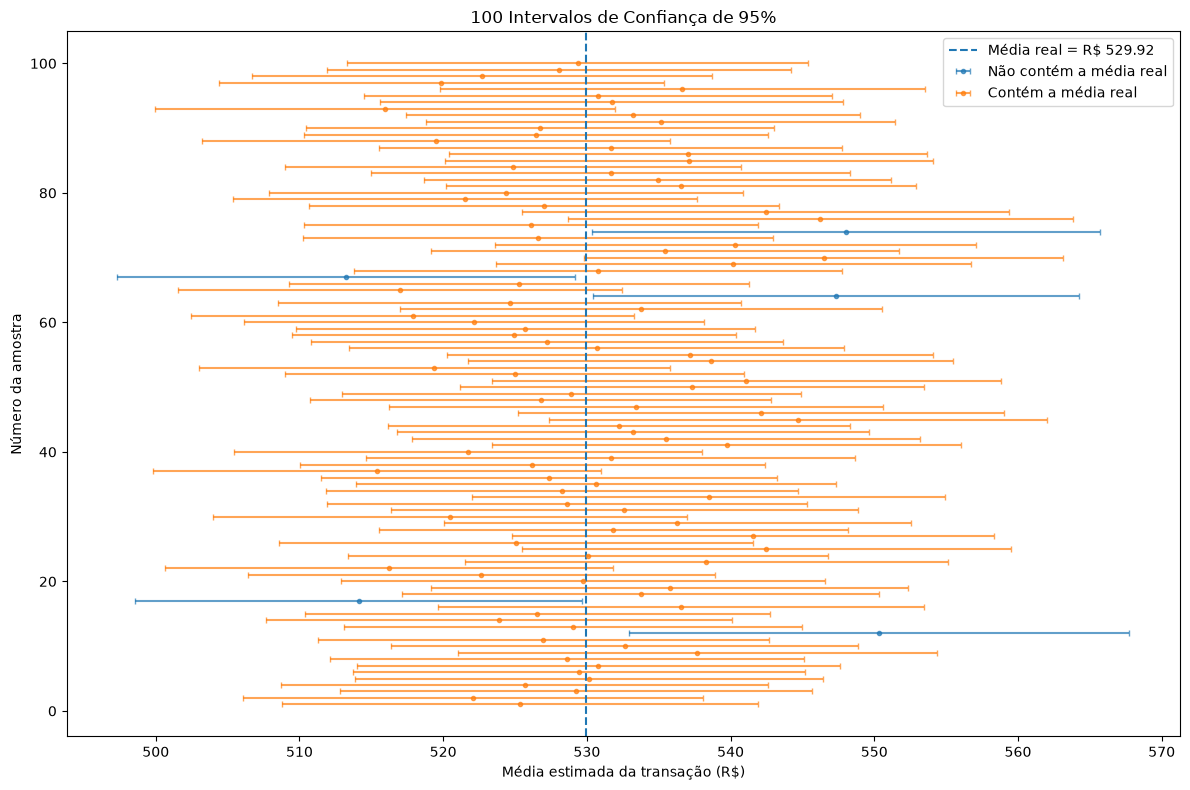

In [21]:
plt.figure(figsize=(12, 8))

ax = plt.gca()

for contem_media, grupo in df_ic.groupby("contem_media_real"):
    erro_esquerda = grupo["media"] - grupo["limite_inferior"]
    erro_direita = grupo["limite_superior"] - grupo["media"]

    ax.errorbar(
        grupo["media"],
        grupo["amostra"],
        xerr=np.vstack([erro_esquerda, erro_direita]),
        fmt="o",
        markersize=3,
        alpha=0.7,
        capsize=2,
        label=(
            "Contém a média real"
            if contem_media
            else "Não contém a média real"
        )
    )

ax.axvline(
    media_populacao,
    linestyle="--",
    linewidth=1.5,
    label=f"Média real = R$ {media_populacao:.2f}"
)

plt.title("100 Intervalos de Confiança de 95%")
plt.xlabel("Média estimada da transação (R$)")
plt.ylabel("Número da amostra")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../imagens/intervalos_confianca_100.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 3.2 Validação com 1.000 amostras

A primeira simulação utilizou 100 amostras e exatamente 95% dos intervalos
de confiança continham a média verdadeira da população.

Como esse resultado poderia ter ocorrido por variação aleatória, o experimento
será repetido com **1.000 amostras aleatórias de 10.000 transações**.

O objetivo é verificar se, com um número maior de repetições, a proporção de
intervalos que contém a média real permanece próxima do nível de confiança
teórico de 95%.

In [22]:
resultados_1000 = []

for i in range(1000):

    amostra = df["valor_bruto"].sample(
        n=10000,
        random_state=i + 1000
    )

    media = amostra.mean()
    desvio = amostra.std(ddof=1)

    erro_padrao = desvio / np.sqrt(len(amostra))
    margem_erro = 1.96 * erro_padrao

    limite_inferior = media - margem_erro
    limite_superior = media + margem_erro

    contem_media_real = (
        limite_inferior <= media_populacao <= limite_superior
    )

    resultados_1000.append({
        "amostra": i + 1,
        "media": media,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "contem_media_real": contem_media_real
    })

df_ic_1000 = pd.DataFrame(resultados_1000)

In [23]:
quantidade_dentro = df_ic_1000["contem_media_real"].sum()
percentual_dentro = df_ic_1000["contem_media_real"].mean() * 100

print(f"Intervalos contendo a média real: {quantidade_dentro}/1000")
print(f"Percentual: {percentual_dentro:.2f}%")

Intervalos contendo a média real: 962/1000
Percentual: 96.20%


In [24]:
valores = df["valor_bruto"].to_numpy()

media_populacao = valores.mean()

n_amostra = 10000
qtd_repeticoes = 10000

rng = np.random.default_rng(42)

acertos = 0

for i in range(qtd_repeticoes):

    amostra = rng.choice(
        valores,
        size=n_amostra,
        replace=False
    )

    media = amostra.mean()
    desvio = amostra.std(ddof=1)

    erro_padrao = desvio / np.sqrt(n_amostra)
    margem_erro = 1.96 * erro_padrao

    limite_inferior = media - margem_erro
    limite_superior = media + margem_erro

    if limite_inferior <= media_populacao <= limite_superior:
        acertos += 1


percentual = acertos / qtd_repeticoes * 100

print(f"Intervalos contendo a média real: {acertos}/{qtd_repeticoes}")
print(f"Percentual: {percentual:.2f}%")

Intervalos contendo a média real: 9539/10000
Percentual: 95.39%


### 3.3 Validação do nível de confiança com 10.000 repetições

Na primeira simulação foram geradas **100 amostras aleatórias**, cada uma contendo
10.000 transações. O resultado mostrou que **95 dos 100 intervalos de confiança**
continham a média real da população, correspondendo exatamente a 95%.

Como esse resultado poderia ter sido influenciado pela variação aleatória,
o experimento foi repetido aumentando progressivamente a quantidade de
simulações, mantendo o tamanho de cada amostra em 10.000 transações.

#### Simulação com 1.000 amostras

Foram construídos 1.000 intervalos de confiança de 95%.

Resultado:

- Intervalos contendo a média real: **962 de 1.000**
- Cobertura observada: **96,20%**
- Cobertura teórica esperada: **95%**

O resultado mostrou que a taxa observada não precisa ser exatamente 95% em
cada experimento. Existe variação aleatória entre diferentes conjuntos de
amostras.

#### Simulação com 10.000 amostras

O experimento foi ampliado novamente, desta vez para **10.000 amostras
independentes**, mantendo 10.000 transações em cada amostra.

Resultado:

- Intervalos contendo a média real: **9.539 de 10.000**
- Cobertura observada: **95,39%**
- Cobertura teórica esperada: **95%**

### Comparação dos resultados

| Número de simulações | Intervalos contendo a média | Cobertura observada |
|---:|---:|---:|
| 100 | 95 | 95,00% |
| 1.000 | 962 | 96,20% |
| 10.000 | 9.539 | 95,39% |

À medida que aumentamos a quantidade de repetições, conseguimos observar com
mais clareza o comportamento de longo prazo do método.

O resultado de **95,39% em 10.000 simulações** ficou muito próximo dos 95%
teóricos, reforçando a interpretação correta do intervalo de confiança:
não se espera que exatamente 95 de cada 100 intervalos contenham o parâmetro
verdadeiro em todo experimento, mas que, ao repetir o procedimento muitas vezes,
a proporção de intervalos que contém o verdadeiro parâmetro tenda a permanecer
próxima do nível de confiança definido.

> **Importante:** o tamanho de cada amostra permaneceu em 10.000 transações.
> O que aumentou de 100 para 1.000 e depois para 10.000 foi a quantidade de
> vezes que o experimento de amostragem foi repetido.


## 4. Covariância e correlação

Até aqui analisamos principalmente uma variável isoladamente, como o
`valor_bruto`.

Agora o objetivo é começar a estudar a relação entre duas variáveis.

Nesta etapa serão investigadas relações como:

- valor da transação × tempo de processamento;
- valor da transação × quantidade de parcelas.

### Covariância

A covariância indica se duas variáveis tendem a variar na mesma direção.

- Covariância positiva: quando uma aumenta, a outra tende a aumentar.
- Covariância negativa: quando uma aumenta, a outra tende a diminuir.
- Covariância próxima de zero: não há uma tendência linear evidente.

Entretanto, a magnitude da covariância depende da escala das variáveis,
dificultando comparações.

### Correlação

A correlação padroniza essa relação em uma escala entre -1 e 1.

- Próxima de +1: forte relação linear positiva.
- Próxima de -1: forte relação linear negativa.
- Próxima de 0: pouca ou nenhuma relação linear.

> Correlação não implica causalidade. Encontrar uma relação entre duas
> variáveis não significa que uma seja necessariamente a causa da outra.

### Pergunta desta etapa

> Existem relações lineares relevantes entre o valor das transações,
> o tempo de processamento e a quantidade de parcelas?

In [25]:
query_relacoes = """
SELECT
    valor_bruto,
    tempo_processamento_ms,
    quantidade_parcelas
FROM transacoes;
"""

df_relacoes = pd.read_sql(query_relacoes, engine)

df_relacoes.head()

,valor_bruto,tempo_processamento_ms,quantidade_parcelas
0,825.77,993,9
1,3506.10,1021,11
2,46.50,590,1
3,550.48,1398,3
4,68.84,369,1


In [26]:
df_relacoes.cov()

,valor_bruto,tempo_processamento_ms,quantidade_parcelas
valor_bruto,696363.185697,40489.132296,1101.521267
tempo_processamento_ms,40489.132296,86516.487704,201.718509
quantidade_parcelas,1101.521267,201.718509,6.089192


In [27]:
correlacao = df_relacoes.corr(method="pearson")

correlacao

,valor_bruto,tempo_processamento_ms,quantidade_parcelas
valor_bruto,1.000000,0.164957,0.534928
tempo_processamento_ms,0.164957,1.000000,0.277918
quantidade_parcelas,0.534928,0.277918,1.000000


In [28]:
corr_valor_tempo = df_relacoes[
    ["valor_bruto", "tempo_processamento_ms"]
].corr().iloc[0, 1]

print(
    f"Correlação valor × processamento: "
    f"{corr_valor_tempo:.4f}"
)

Correlação valor × processamento: 0.1650


In [29]:
corr_valor_parcelas = df_relacoes[
    ["valor_bruto", "quantidade_parcelas"]
].corr().iloc[0, 1]

print(
    f"Correlação valor × parcelas: "
    f"{corr_valor_parcelas:.4f}"
)

Correlação valor × parcelas: 0.5349


In [30]:
query_credito = """
SELECT
    t.valor_bruto,
    t.quantidade_parcelas
FROM transacoes t
JOIN meios_pagamento m
    ON t.meio_pagamento_id = m.meio_pagamento_id
WHERE m.meio_pagamento = 'Crédito';
"""

df_credito = pd.read_sql(query_credito, engine)

corr_credito = df_credito[
    ["valor_bruto", "quantidade_parcelas"]
].corr(method="pearson")

corr_credito

,valor_bruto,quantidade_parcelas
valor_bruto,1.000000,0.559849
quantidade_parcelas,0.559849,1.000000


In [31]:
df_relacoes.corr(method="spearman")

,valor_bruto,tempo_processamento_ms,quantidade_parcelas
valor_bruto,1.000000,0.191647,0.502071
tempo_processamento_ms,0.191647,1.000000,0.353440
quantidade_parcelas,0.502071,0.353440,1.000000


In [32]:
pearson = df_relacoes.corr(method="pearson")
spearman = df_relacoes.corr(method="spearman")

comparacao_correlacao = pd.DataFrame({
    "Pearson": [
        pearson.loc["valor_bruto", "tempo_processamento_ms"],
        pearson.loc["valor_bruto", "quantidade_parcelas"],
        pearson.loc["tempo_processamento_ms", "quantidade_parcelas"]
    ],
    "Spearman": [
        spearman.loc["valor_bruto", "tempo_processamento_ms"],
        spearman.loc["valor_bruto", "quantidade_parcelas"],
        spearman.loc["tempo_processamento_ms", "quantidade_parcelas"]
    ]
}, index=[
    "Valor × Tempo de processamento",
    "Valor × Quantidade de parcelas",
    "Tempo de processamento × Parcelas"
])

comparacao_correlacao.round(3)

,Pearson,Spearman
Valor × Tempo de processamento,0.165,0.192
Valor × Quantidade de parcelas,0.535,0.502
Tempo de processamento × Parcelas,0.278,0.353


### Visual 4 — Matriz de correlação de Pearson

O mapa de calor resume a direção e a força das relações lineares entre as variáveis analisadas.


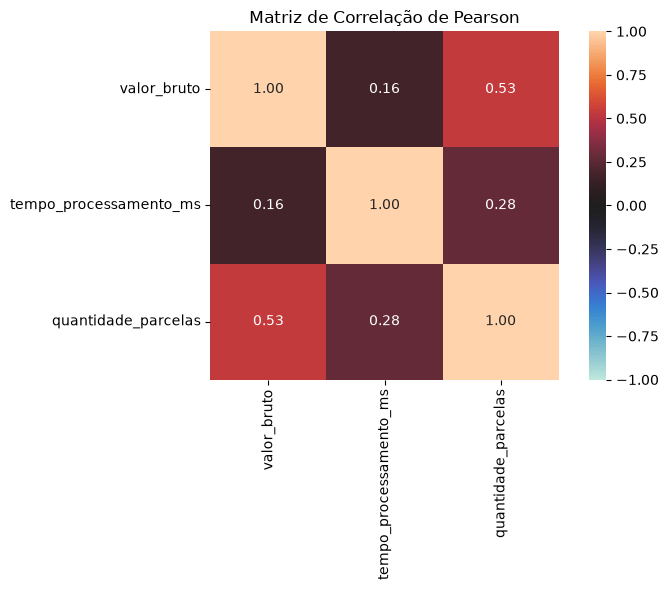

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Matriz de Correlação de Pearson")
plt.tight_layout()

plt.savefig(
    "../imagens/matriz_correlacao_pearson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Visual 5 — Ticket por quantidade de parcelas no Crédito

Como a principal associação encontrada foi entre valor e quantidade de parcelas, este gráfico mostra a evolução da média e da mediana do ticket somente nas transações de Crédito.


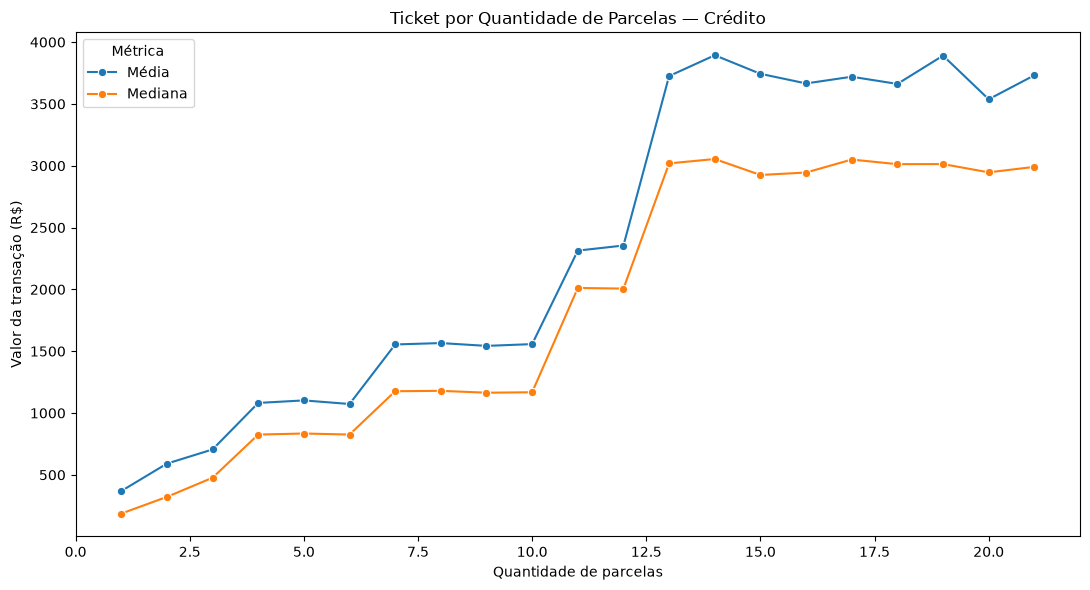

In [34]:
ticket_por_parcela = (
    df_credito
    .groupby("quantidade_parcelas")["valor_bruto"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={
        "mean": "Média",
        "median": "Mediana",
        "count": "Quantidade"
    })
)

ticket_por_parcela_long = ticket_por_parcela.melt(
    id_vars=["quantidade_parcelas", "Quantidade"],
    value_vars=["Média", "Mediana"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=ticket_por_parcela_long,
    x="quantidade_parcelas",
    y="Valor",
    hue="Métrica",
    marker="o"
)

plt.title("Ticket por Quantidade de Parcelas — Crédito")
plt.xlabel("Quantidade de parcelas")
plt.ylabel("Valor da transação (R$)")
plt.tight_layout()

plt.savefig(
    "../imagens/ticket_por_parcelas_credito.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Interpretação das correlações

Os coeficientes de Pearson e Spearman apresentaram resultados semelhantes para
as principais relações analisadas.

A relação mais relevante foi observada entre **valor da transação e quantidade
de parcelas**, com correlação de aproximadamente **0,53 em Pearson** e **0,50
em Spearman**, indicando uma associação positiva moderada.

Isso sugere que transações de maior valor tendem a apresentar maior quantidade
de parcelas.

Já a relação entre **valor da transação e tempo de processamento** apresentou
correlação baixa em ambos os métodos, indicando pouca associação entre essas
variáveis.

A relação entre **tempo de processamento e quantidade de parcelas** também foi
positiva, porém mais fraca.

Como correlação não implica causalidade, esses resultados devem ser tratados
como evidências de associação e não como prova de que uma variável causa a outra.

## 5. Teste de hipótese e p-valor

Após identificar diferenças no comportamento dos valores transacionados entre
os segmentos, o próximo passo é avaliar se uma diferença observada pode ser
explicada apenas pela variabilidade dos dados ou se existe evidência estatística
de uma diferença entre os grupos.

Nesta etapa serão comparados os segmentos **Hotelaria** e **Eletrônicos**,
que apresentaram tickets elevados durante a análise exploratória.

### Pergunta

> O ticket médio de Hotelaria e Eletrônicos é estatisticamente diferente?

### Hipóteses

**Hipótese nula (H0):**

> O ticket médio de Hotelaria e Eletrônicos é igual.

**Hipótese alternativa (H1):**

> O ticket médio de Hotelaria e Eletrônicos é diferente.

Será utilizado inicialmente um nível de significância de **5% (α = 0,05)**.

O p-valor será utilizado para avaliar o quanto os resultados observados seriam
incompatíveis com a hipótese nula.

In [35]:
query_teste = """
SELECT
    t.valor_bruto,
    e.segmento
FROM transacoes t
JOIN estabelecimentos e
    ON t.estabelecimento_id = e.estabelecimento_id
WHERE e.segmento IN ('Hotelaria', 'Eletrônicos');
"""

df_teste = pd.read_sql(query_teste, engine)

df_teste.groupby("segmento")["valor_bruto"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
segmento,,,,
Eletrônicos,46581,1422.75,1040.90,1316.76
Hotelaria,49184,1458.48,1113.38,1225.18


In [36]:
hotelaria = df_teste.loc[
    df_teste["segmento"] == "Hotelaria",
    "valor_bruto"
]

eletronicos = df_teste.loc[
    df_teste["segmento"] == "Eletrônicos",
    "valor_bruto"
]

estatistica_t, p_valor = ttest_ind(
    hotelaria,
    eletronicos,
    equal_var=False
)

print(f"Estatística t: {estatistica_t:.4f}")
print(f"P-valor: {p_valor:.10f}")

Estatística t: 4.3410
P-valor: 0.0000142005


In [37]:
alpha = 0.05

if p_valor < alpha:
    print("Rejeitamos H0.")
    print("Há evidência estatística de diferença entre as médias.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência suficiente de diferença entre as médias.")

Rejeitamos H0.
Há evidência estatística de diferença entre as médias.


### 5.1 Tamanho do efeito — Cohen's d

O teste de hipótese indicou evidência estatística de diferença entre os
tickets médios de Hotelaria e Eletrônicos.

Entretanto, um p-valor baixo não informa o tamanho dessa diferença.

Com grandes volumes de dados, diferenças pequenas podem se tornar
estatisticamente significativas.

Por isso, será calculado o **Cohen's d**, uma medida padronizada do tamanho
do efeito.

Interpretação aproximada:

- |d| ≈ 0,2 → efeito pequeno
- |d| ≈ 0,5 → efeito moderado
- |d| ≈ 0,8 → efeito grande

O objetivo é responder:

> A diferença detectada entre Hotelaria e Eletrônicos também possui
> relevância prática, ou é apenas estatisticamente detectável?

In [38]:
media_hotelaria = hotelaria.mean()
media_eletronicos = eletronicos.mean()

std_hotelaria = hotelaria.std(ddof=1)
std_eletronicos = eletronicos.std(ddof=1)

n_hotelaria = len(hotelaria)
n_eletronicos = len(eletronicos)

# Desvio padrão combinado dos dois grupos
std_pooled = np.sqrt(
    (
        (n_hotelaria - 1) * std_hotelaria**2
        + (n_eletronicos - 1) * std_eletronicos**2
    )
    /
    (n_hotelaria + n_eletronicos - 2)
)

cohen_d = (
    media_hotelaria - media_eletronicos
) / std_pooled

diferenca_reais = media_hotelaria - media_eletronicos

diferenca_percentual = (
    diferenca_reais / media_eletronicos * 100
)

print(f"Média Hotelaria: R$ {media_hotelaria:.2f}")
print(f"Média Eletrônicos: R$ {media_eletronicos:.2f}")
print(f"Diferença absoluta: R$ {diferenca_reais:.2f}")
print(f"Diferença percentual: {diferenca_percentual:.2f}%")
print(f"Cohen's d: {cohen_d:.4f}")

Média Hotelaria: R$ 1458.48
Média Eletrônicos: R$ 1422.75
Diferença absoluta: R$ 35.73
Diferença percentual: 2.51%
Cohen's d: 0.0281


### Interpretação do tamanho do efeito

O teste de Welch identificou diferença estatisticamente significativa entre
os tickets médios de Hotelaria e Eletrônicos (`p < 0,05`).

Entretanto, a diferença absoluta entre as médias foi de apenas **R$ 35,73**,
equivalente a aproximadamente **2,51%**.

O Cohen's d calculado foi de **0,0281**, indicando um tamanho de efeito
extremamente pequeno.

Portanto, apesar de a diferença ser estatisticamente detectável devido ao
grande volume de observações, sua magnitude é pequena quando comparada à
variabilidade existente nos dois segmentos.

Esse resultado evidencia a importância de analisar conjuntamente
**significância estatística e relevância prática**, evitando conclusões
baseadas exclusivamente no p-valor.

## 6. ANOVA — comparação entre vários segmentos

Até aqui foi realizada uma comparação entre dois segmentos utilizando o
teste t de Welch.

Agora o objetivo é avaliar simultaneamente se existem diferenças entre os
tickets médios de vários segmentos.

### Pergunta

> Os diferentes segmentos possuem o mesmo ticket médio ou existe pelo menos
> um segmento com comportamento estatisticamente diferente?

### Hipóteses

**H0 — Hipótese nula**

> Todos os segmentos possuem a mesma média de `valor_bruto`.

**H1 — Hipótese alternativa**

> Pelo menos um dos segmentos possui média diferente.

Será utilizado nível de significância de **5% (α = 0,05)**.

A ANOVA não identifica diretamente qual grupo é diferente.
Ela responde primeiro se existe evidência de diferença no conjunto.

In [39]:
query_anova = """
SELECT
    t.valor_bruto,
    e.segmento
FROM transacoes t
JOIN estabelecimentos e
    ON t.estabelecimento_id = e.estabelecimento_id;
"""
    
df_anova = pd.read_sql(query_anova, engine)

In [40]:
resumo_segmentos = (
    df_anova
    .groupby("segmento")["valor_bruto"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .sort_values("mean", ascending=False)
)

resumo_segmentos

,count,mean,median,std
segmento,,,,
Hotelaria,49184,1458.48,1113.38,1225.18
Eletrônicos,46581,1422.75,1040.90,1316.76
Saúde,41899,1132.61,801.49,1127.02
Educação,37091,957.01,781.29,674.63
Serviços,44045,675.39,493.41,630.71
Vestuário,65750,372.11,296.53,284.02
Supermercado,84242,173.66,144.82,115.13
Farmácia,67051,118.34,96.56,84.61
Alimentação,89281,89.96,75.21,59.31


### Visual 6 — Perfil de ticket por segmento

A comparação entre média e mediana por segmento ajuda a visualizar tanto as diferenças entre grupos quanto o efeito da assimetria dentro de cada segmento.


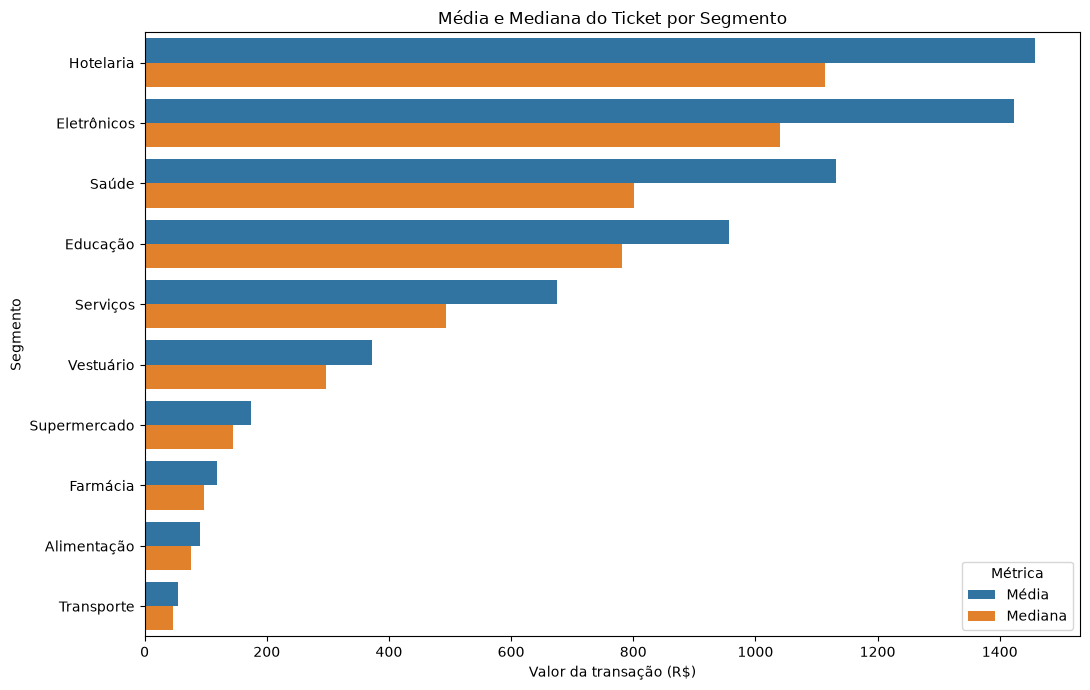

In [41]:
segmentos_plot = (
    resumo_segmentos
    .reset_index()[["segmento", "mean", "median"]]
    .rename(columns={
        "mean": "Média",
        "median": "Mediana"
    })
)

ordem_segmentos = segmentos_plot.sort_values(
    "Média",
    ascending=False
)["segmento"]

segmentos_long = segmentos_plot.melt(
    id_vars="segmento",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=segmentos_long,
    y="segmento",
    x="Valor",
    hue="Métrica",
    order=ordem_segmentos
)

plt.title("Média e Mediana do Ticket por Segmento")
plt.xlabel("Valor da transação (R$)")
plt.ylabel("Segmento")
plt.tight_layout()

plt.savefig(
    "../imagens/ticket_por_segmento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [42]:
grupos = [
    grupo["valor_bruto"].values
    for _, grupo in df_anova.groupby("segmento")
]

In [43]:
from scipy.stats import f_oneway

estatistica_f, p_valor_anova = f_oneway(*grupos)

print(f"Estatística F: {estatistica_f:.4f}")
print(f"P-valor: {p_valor_anova:.10f}")

Estatística F: 40629.5935
P-valor: 0.0000000000


In [44]:
alpha = 0.05

if p_valor_anova < alpha:
    print("Rejeitamos H0.")
    print("Existe evidência de diferença entre os segmentos.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência suficiente de diferença entre os segmentos.")

Rejeitamos H0.
Existe evidência de diferença entre os segmentos.


### 6.1 Verificação da homogeneidade das variâncias

A ANOVA tradicional pressupõe que os grupos apresentem variâncias
aproximadamente homogêneas.

Como os segmentos possuem desvios padrão bastante diferentes, será utilizado
o teste de Levene para avaliar essa condição.

### Hipóteses

**H0:** as variâncias dos segmentos são iguais.

**H1:** pelo menos um segmento apresenta variância diferente.

Será considerado nível de significância de 5% (`α = 0,05`).

In [45]:
estatistica_levene, p_levene = levene(
    *grupos,
    center="median"
)

print(f"Estatística de Levene: {estatistica_levene:.4f}")
print(f"P-valor: {p_levene:.10f}")

Estatística de Levene: 18849.7734
P-valor: 0.0000000000


In [46]:
alpha = 0.05

if p_levene < alpha:
    print("Rejeitamos H0.")
    print("As variâncias dos segmentos não são homogêneas.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência suficiente de diferença entre as variâncias.")

Rejeitamos H0.
As variâncias dos segmentos não são homogêneas.


### Interpretação do teste de Levene

O teste de Levene apresentou evidência estatística de que as variâncias dos
segmentos não são homogêneas (`p < 0,05`).

Esse resultado confirma o comportamento observado anteriormente nos desvios
padrão, que variam significativamente entre segmentos.

Como a homogeneidade das variâncias é uma das premissas da ANOVA tradicional,
o resultado indica que uma abordagem mais adequada é utilizar a
**ANOVA de Welch**, que não exige igualdade das variâncias entre os grupos.

Assim, o resultado da ANOVA tradicional será mantido como parte do processo
exploratório, mas a conclusão será validada utilizando um método mais adequado
às características dos dados.

In [47]:
estatistica_welch, p_welch = f_oneway(
    *grupos,
    equal_var=False
)

print(f"Estatística F (Welch): {estatistica_welch:.4f}")
print(f"P-valor: {p_welch:.10e}")

Estatística F (Welch): 46578.9914
P-valor: 0.0000000000e+00


In [48]:
alpha = 0.05

if p_welch < alpha:
    print("Rejeitamos H0.")
    print("Existe evidência de diferença entre as médias dos segmentos.")
else:
    print("Não rejeitamos H0.")
    print("Não há evidência suficiente de diferença entre as médias.")

Rejeitamos H0.
Existe evidência de diferença entre as médias dos segmentos.


### 6.2 Comparações pós-hoc — Games-Howell

A ANOVA de Welch indicou que existe diferença estatisticamente significativa
entre os tickets médios dos segmentos.

Entretanto, esse teste responde apenas se existe pelo menos uma diferença no
conjunto, sem identificar quais pares de segmentos apresentam comportamentos
distintos.

Como o teste de Levene identificou variâncias não homogêneas, será utilizado
o teste pós-hoc de **Games-Howell**, adequado para comparações entre grupos
com variâncias e tamanhos de amostra diferentes.

Além do p-valor, será observado o tamanho do efeito de cada comparação,
evitando interpretar significância estatística como relevância prática.


In [49]:
games_howell = pg.pairwise_gameshowell(
    data=df_anova,
    dv="valor_bruto",
    between="segmento",
    effsize="hedges"
)

games_howell.head()

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Alimentação,Educação,89.957462,957.008890,-867.051428,3.508546,-247.125550,37328.377255,0.000000e+00,-2.350543
1,Alimentação,Eletrônicos,89.957462,1422.754736,-1332.797274,6.104261,-218.338835,46678.620491,4.034240e-11,-1.725271
2,Alimentação,Farmácia,89.957462,118.336528,-28.379066,0.382313,-74.229927,114001.281643,1.110223e-16,-0.398200
3,Alimentação,Hotelaria,89.957462,1458.483271,-1368.525809,5.527995,-247.562763,49310.007749,3.877365e-11,-1.870204
4,Alimentação,Saúde,89.957462,1132.605176,-1042.647714,5.509472,-189.246406,42006.931033,3.160283e-11,-1.632156


In [50]:
resultado_games = games_howell[
    [
        "A",
        "B",
        "mean_A",
        "mean_B",
        "diff",
        "pval",
        "hedges"
    ]
].copy()

resultado_games["significativo"] = (
    resultado_games["pval"] < 0.05
)

resultado_games.round(4)

,A,B,mean_A,mean_B,diff,pval,hedges,significativo
0,Alimentação,Educação,89.9575,957.0089,-867.0514,0.0000,-2.3505,True
1,Alimentação,Eletrônicos,89.9575,1422.7547,-1332.7973,0.0000,-1.7253,True
2,Alimentação,Farmácia,89.9575,118.3365,-28.3791,0.0000,-0.3982,True
3,Alimentação,Hotelaria,89.9575,1458.4833,-1368.5258,0.0000,-1.8702,True
4,Alimentação,Saúde,89.9575,1132.6052,-1042.6477,0.0000,-1.6322,True
5,Alimentação,Serviços,89.9575,675.3877,-585.4302,0.0000,-1.6007,True
6,Alimentação,Supermercado,89.9575,173.6603,-83.7028,0.0000,-0.9218,True
7,Alimentação,Transporte,89.9575,54.8697,35.0878,0.0000,0.6882,True
8,Alimentação,Vestuário,89.9575,372.1147,-282.1572,0.0000,-1.4822,True
9,Educação,Eletrônicos,957.0089,1422.7547,-465.7458,0.0000,-0.4311,True


In [51]:
resultado_games["efeito_abs"] = resultado_games["hedges"].abs()

def classificar_efeito(valor):
    if valor < 0.2:
        return "Desprezível"
    elif valor < 0.5:
        return "Pequeno"
    elif valor < 0.8:
        return "Moderado"
    else:
        return "Grande"


resultado_games["magnitude_efeito"] = (
    resultado_games["efeito_abs"]
    .apply(classificar_efeito)
)


resultado_games.sort_values(
    "efeito_abs",
    ascending=False
)[
    [
        "A",
        "B",
        "mean_A",
        "mean_B",
        "diff",
        "pval",
        "hedges",
        "magnitude_efeito"
    ]
].round(4)

,A,B,mean_A,mean_B,diff,pval,hedges,magnitude_efeito
0,Alimentação,Educação,89.9575,957.0089,-867.0514,0.0000,-2.3505,Grande
15,Educação,Transporte,957.0089,54.8697,902.1392,0.0000,2.1354,Grande
10,Educação,Farmácia,957.0089,118.3365,838.6724,0.0000,2.0541,Grande
14,Educação,Supermercado,957.0089,173.6603,783.3486,0.0000,2.0339,Grande
3,Alimentação,Hotelaria,89.9575,1458.4833,-1368.5258,0.0000,-1.8702,Grande
1,Alimentação,Eletrônicos,89.9575,1422.7547,-1332.7973,0.0000,-1.7253,Grande
32,Hotelaria,Supermercado,1458.4833,173.6603,1284.8230,0.0000,1.7143,Grande
33,Hotelaria,Transporte,1458.4833,54.8697,1403.6136,0.0000,1.6895,Grande
24,Farmácia,Hotelaria,118.3365,1458.4833,-1340.1467,0.0000,-1.6761,Grande
4,Alimentação,Saúde,89.9575,1132.6052,-1042.6477,0.0000,-1.6322,Grande


### Visual 7 — Distribuição das magnitudes de efeito

O gráfico resume quantas comparações pós-hoc apresentam efeito desprezível, pequeno, moderado ou grande. Isso reforça visualmente que significância estatística e relevância prática são conceitos diferentes.


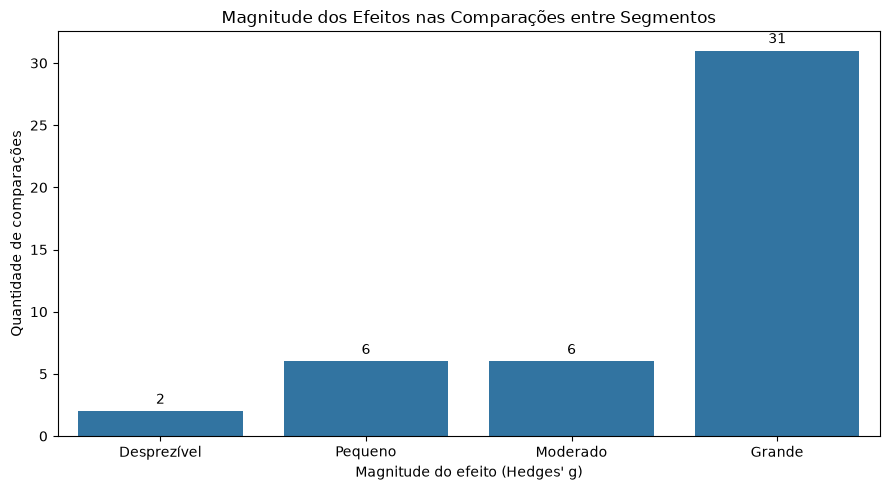

In [52]:
ordem_efeito = [
    "Desprezível",
    "Pequeno",
    "Moderado",
    "Grande"
]

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=resultado_games,
    x="magnitude_efeito",
    order=ordem_efeito
)

plt.title("Magnitude dos Efeitos nas Comparações entre Segmentos")
plt.xlabel("Magnitude do efeito (Hedges' g)")
plt.ylabel("Quantidade de comparações")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()

plt.savefig(
    "../imagens/magnitude_efeitos_segmentos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [53]:
resultado_games[
    (resultado_games["significativo"])
    & (resultado_games["efeito_abs"] < 0.2)
][
    [
        "A",
        "B",
        "diff",
        "pval",
        "hedges",
        "magnitude_efeito"
    ]
].round(4)

,A,B,diff,pval,hedges,magnitude_efeito
12,Educação,Saúde,-175.5963,0.0000,-0.1864,Desprezível
18,Eletrônicos,Hotelaria,-35.7285,0.0006,-0.0281,Desprezível


### 6.3 Classificação da magnitude do efeito

Após identificar quais pares de segmentos apresentam diferenças
estatisticamente significativas, o próximo passo é avaliar a **magnitude dessas
diferenças**.

Para isso, foi utilizado o **Hedges' g**, uma medida padronizada de tamanho do
efeito.

O sinal positivo ou negativo indica apenas a direção da diferença entre os
grupos. Para avaliar a magnitude, é utilizado o valor absoluto do coeficiente.

Como referência prática, foi adotada a seguinte classificação:

- **|g| < 0,20:** efeito desprezível
- **0,20 ≤ |g| < 0,50:** efeito pequeno
- **0,50 ≤ |g| < 0,80:** efeito moderado
- **|g| ≥ 0,80:** efeito grande

Esses limites funcionam como referências e não devem ser interpretados como
regras absolutas. A relevância da diferença também depende do contexto de
negócio.

### Interpretação

Os resultados mostram que muitos pares de segmentos apresentam diferenças
estatisticamente significativas, porém a magnitude dessas diferenças varia
consideravelmente.

Por exemplo, **Eletrônicos e Hotelaria** apresentam diferença estatisticamente
significativa, mas Hedges' g próximo de zero, indicando um efeito praticamente
desprezível.

Em contraste, comparações entre segmentos com estruturas de ticket muito
diferentes apresentam efeitos classificados como grandes.

Esse resultado reforça que o **p-valor identifica evidência de diferença**,
enquanto o **tamanho do efeito indica a magnitude dessa diferença**.

Portanto, decisões analíticas não devem ser baseadas exclusivamente na
significância estatística.

## Encerramento

### Síntese dos principais achados

Este notebook percorreu a distribuição de `valor_bruto` e evoluiu até comparações formais entre segmentos, sempre voltando à pergunta de negócio original: os tickets elevados são anomalias ou comportamentos esperados de determinados segmentos?

- A distribuição dos valores é fortemente assimétrica à direita (assimetria de 4,44, curtose de 36,74) — a média (R$ 529,92) não representa bem o comportamento típico; a mediana (R$ 205,00) e os percentis descrevem melhor.
- Cerca de 9% das transações ficaram acima do limite superior do IQR (R$ 1.476,72), concentradas principalmente em Hotelaria, Eletrônicos e Saúde — reforçando que um outlier estatístico não é automaticamente um erro ou uma anomalia de negócio.
- Uma amostra aleatória de 10 mil registros reproduziu bem o comportamento da população; uma amostra restrita a Hotelaria mostrou viés forte, evidenciando que tamanho de amostra não garante representatividade.
- O intervalo de confiança de 95% construído a partir da amostra aleatória capturou a média real da população, e a cobertura se manteve próxima de 95% em simulações repetidas (100, 1.000 e 10.000 vezes).
- Valor da transação e quantidade de parcelas apresentaram a correlação mais forte do estudo (Pearson 0,535 / Spearman 0,502); valor e tempo de processamento, a mais fraca.
- A diferença de ticket médio entre Hotelaria e Eletrônicos foi estatisticamente significativa (Welch t, p = 0,0000142), mas com tamanho de efeito praticamente desprezível (Cohen's d = 0,0281) — o lembrete central do estudo: significância estatística não é o mesmo que relevância prática.
- A comparação entre múltiplos segmentos (ANOVA de Welch + Games-Howell + Hedges' g, aplicada após o teste de Levene indicar variâncias heterogêneas) mostrou que a magnitude das diferenças varia de desprezível a grande, dependendo do par de segmentos.

### Próxima etapa

A investigação continua em `02_eda_complementar.ipynb`, com foco em Data Quality (completude, duplicidade lógica, consistência referencial), segmentação por bandeira/adquirente/canal/horário, análise temporal e identificação de estabelecimentos fora do padrão — antes de qualquer avanço para Feature Engineering ou Machine Learning.

Após a síntese, a conexão com o PostgreSQL é liberada explicitamente.


In [54]:
engine.dispose()
print("Conexão com o banco de dados encerrada.")


Conexão com o banco de dados encerrada.
